# Phase 3 — demand-distribution & staging analytics

Re-runnable analytics for the coverage matrix. Edit the **CONFIG** cell to change thresholds, colours or labels, then *Run All*.

- **Breadth Σ** = total demand volume per topic.
- **Convergence** = number of the 4 stakeholder channels (Reg/Cust/Inv/NGO) demanding the topic.
- **Stage 1 (build first)** = Conv ≥ `CONV_CUT` **AND** Breadth ≥ `BREADTH_CUT`.


## 1. Config — edit these

In [6]:
# --- thresholds (the two knobs) ---
CONV_CUT    = 3      # min. number of stakeholder channels for Stage 1/2
BREADTH_CUT = 12     # min. breadth for Stage 1 (default = Q3 of the distribution)

# --- data source ---
# Option A: read live from the workbook (set the path to your file).
# Option B: if the file is not found, the embedded snapshot below is used.
EXCEL_PATH  = 'Phase3_Coverage_Matrix_v17.xlsx'
SHEET       = 'Coverage matrix'

# --- styling ---
NAVY='#1F4E79'; GREEN='#A7C272'; GREENF='#E3EECF'; RED='#C0504D'


## 2. Load data (live from Excel, else embedded snapshot)

In [7]:
import statistics
from collections import Counter

# embedded snapshot (auto-generated; used only if the Excel file is absent)
SNAPSHOT = [["E1-3", 7, 4], ["E1-4", 8, 3], ["E1-5", 12, 3], ["E1-6", 15, 4], ["E3-1", 6, 2], ["E3-2", 1, 1], ["E3-3", 3, 1], ["E3-4", 16, 3], ["E5-2", 4, 3], ["E5-4", 4, 3], ["E5-5", 12, 4], ["G1-1", 9, 4], ["G1-3", 5, 2], ["G1-4", 4, 2], ["G1-5", 2, 1], ["S1-1", 9, 2], ["S1-14", 12, 3], ["S1-17", 11, 4], ["S1-2", 5, 2], ["S1-3", 5, 2], ["S1-4", 4, 2], ["S1-6", 6, 2], ["S1-9", 7, 3], ["S2-1", 15, 3], ["S2-2", 2, 1], ["S2-3", 3, 2], ["Biodiversity & ecosystems (E4)", 19, 4], ["Consumers & end-users (S4)", 8, 3], ["Supply-chain traceability (chain of custody)", 22, 3], ["Wild-stock status / sustainable wild sourcing", 12, 4], ["Feed & marine ingredients sourcing", 10, 3], ["Animal health & welfare (incl. antimicrobial use)", 9, 2]]

def load_from_excel(path, sheet):
    import openpyxl
    w = openpyxl.load_workbook(path, data_only=True)[sheet]
    def col(h):
        for c in range(33,46):
            if str(w.cell(5,c).value or '').strip()==h: return c
    br, cv = col('Breadth \u03a3'), col('Conv (0-4)')
    out=[]
    for r in range(6,38):
        t=w.cell(r,2).value
        if t: out.append([str(t), w.cell(r,br).value or 0, w.cell(r,cv).value or 0])
    return out

try:
    data = load_from_excel(EXCEL_PATH, SHEET)
    print(f'Loaded {len(data)} topics live from {EXCEL_PATH}')
except Exception as e:
    data = SNAPSHOT
    print(f'Using embedded snapshot ({len(data)} topics). [{type(e).__name__}]')


Loaded 32 topics live from Phase3_Coverage_Matrix_v17.xlsx


## 3. Distribution statistics

In [8]:
B = [b for _,b,_ in data]; C = [c for _,_,c in data]
q1,med,q3 = statistics.quantiles(B, n=4)
print(f'Breadth:  min={min(B)}  Q1={q1}  median={med}  Q3={q3}  max={max(B)}  mean={round(statistics.mean(B),1)}')
print('Convergence counts:', dict(sorted(Counter(C).items(), reverse=True)))

stage1 = [(t,b,c) for t,b,c in data if c>=CONV_CUT and b>=BREADTH_CUT]
print(f'\nStage 1 (build first) = {len(stage1)} topics:')
for t,b,c in sorted(stage1, key=lambda x:(-x[2],-x[1])): print(f'  C{c} B{b:>2}  {t}')


Breadth:  min=1  Q1=4.0  median=7.5  Q3=12.0  max=22  mean=8.3
Convergence counts: {4: 7, 3: 11, 2: 10, 1: 4}

Stage 1 (build first) = 9 topics:
  C4 B19  Biodiversity & ecosystems (E4)
  C4 B15  E1-6
  C4 B12  E5-5
  C4 B12  Wild-stock status / sustainable wild sourcing
  C3 B22  Supply-chain traceability (chain of custody)
  C3 B16  E3-4
  C3 B15  S2-1
  C3 B12  E1-5
  C3 B12  S1-14


## 4. Figure — 3 panels (boxplot · convergence bars · staging map)

Matplotlib is building the font cache; this may take a moment.


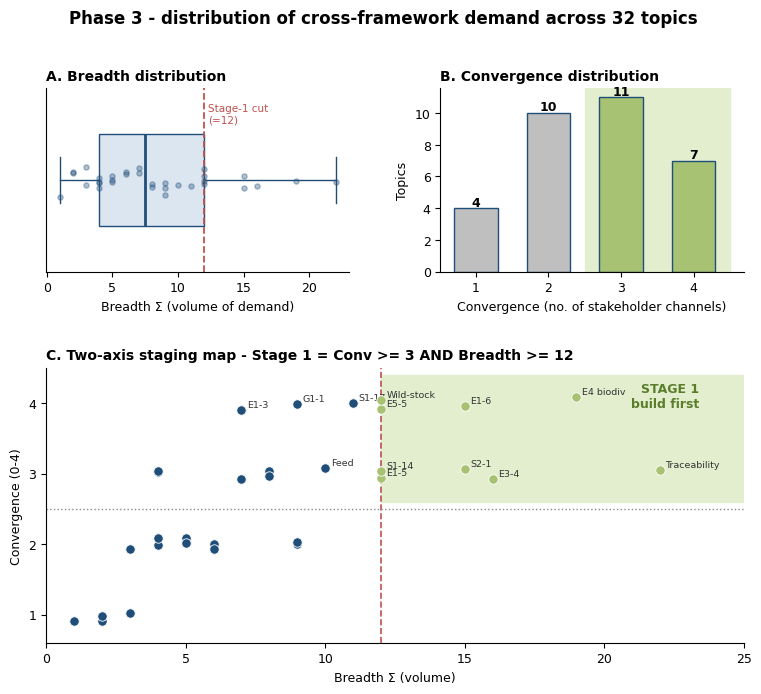

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':9,'axes.spines.top':False,'axes.spines.right':False})
np.random.seed(1)  # stable jitter; change/remove to reshuffle label positions

def short(t):
    repl={'Biodiversity & ecosystems (E4)':'E4 biodiv','Supply-chain traceability (chain of custody)':'Traceability',
          'Wild-stock status / sustainable wild sourcing':'Wild-stock','Feed & marine ingredients sourcing':'Feed',
          'Consumers & end-users (S4)':'S4 consumers','Animal health & welfare (incl. antimicrobial use)':'Animal health/AMU'}
    return repl.get(t, t[:22])

fig = plt.figure(figsize=(9,7.2))
gs = fig.add_gridspec(2,2, height_ratios=[1,1.5], hspace=0.42, wspace=0.30)

# A. breadth boxplot
axA = fig.add_subplot(gs[0,0])
axA.boxplot(B, vert=False, widths=0.5, patch_artist=True,
    boxprops=dict(facecolor='#DCE6F1', color=NAVY), medianprops=dict(color=NAVY, lw=2),
    whiskerprops=dict(color=NAVY), capprops=dict(color=NAVY), flierprops=dict(marker='o', mfc=NAVY, mec=NAVY, ms=4))
axA.scatter(B, np.random.normal(1,0.04,len(B)), s=14, color=NAVY, alpha=0.35, zorder=3)
axA.axvline(BREADTH_CUT, color=RED, ls='--', lw=1.3)
axA.text(BREADTH_CUT+0.3, 1.42, f'Stage-1 cut\n(={BREADTH_CUT})', color=RED, fontsize=7.5, va='top')
axA.set_yticks([]); axA.set_xlabel('Breadth \u03a3 (volume of demand)')
axA.set_title('A. Breadth distribution', fontsize=10, loc='left', weight='bold')

# B. convergence bars
axB = fig.add_subplot(gs[0,1])
cc = Counter(C); xs=[1,2,3,4]; ys=[cc.get(x,0) for x in xs]
cols=[ '#BFBFBF' if x<CONV_CUT else GREEN for x in xs ]
axB.bar(xs, ys, color=cols, edgecolor=NAVY, width=0.6)
for x,y in zip(xs,ys): axB.text(x, y+0.15, y, ha='center', fontsize=9, weight='bold')
axB.axvspan(CONV_CUT-0.5, 4.5, color=GREENF, zorder=0)
axB.set_xticks(xs); axB.set_xlabel('Convergence (no. of stakeholder channels)'); axB.set_ylabel('Topics')
axB.set_title('B. Convergence distribution', fontsize=10, loc='left', weight='bold')

# C. staging map
axC = fig.add_subplot(gs[1,:])
axC.add_patch(Rectangle((BREADTH_CUT, CONV_CUT-0.4), max(B)+3, 4.4-(CONV_CUT-0.4), color=GREENF, zorder=0))
axC.text(max(B)+1.4, 4.3, 'STAGE 1\nbuild first', ha='right', va='top', color='#5a7d2a', fontsize=9, weight='bold')
for t,b,c in data:
    yy = c + np.random.uniform(-0.10,0.10)
    s1 = (b>=BREADTH_CUT and c>=CONV_CUT)
    axC.scatter(b, yy, s=46, color=GREEN if s1 else NAVY, edgecolor='white', lw=0.6, zorder=3)
    if s1 or b>=10 or c==4:
        axC.annotate(short(t),(b,yy), fontsize=6.8, xytext=(4,2), textcoords='offset points', color='#333')
axC.axvline(BREADTH_CUT, color=RED, ls='--', lw=1.2)
axC.axhline(CONV_CUT-0.5, color='#888', ls=':', lw=1)
axC.set_xlabel('Breadth \u03a3 (volume)'); axC.set_ylabel('Convergence (0-4)')
axC.set_yticks([1,2,3,4]); axC.set_ylim(0.6,4.5); axC.set_xlim(0, max(B)+3)
axC.set_title(f'C. Two-axis staging map - Stage 1 = Conv >= {CONV_CUT} AND Breadth >= {BREADTH_CUT}', fontsize=10, loc='left', weight='bold')
fig.suptitle('Phase 3 - distribution of cross-framework demand across 32 topics', fontsize=12, weight='bold', y=0.99)
plt.show()


## 5. Save to PDF / PNG (for the thesis)

In [11]:
fig.savefig('topic_distribution.pdf', bbox_inches='tight')
fig.savefig('topic_distribution.png', dpi=160, bbox_inches='tight')
print('saved topic_distribution.pdf and .png')


saved topic_distribution.pdf and .png
